# Clase 4 — SARSA, Q-Learning y exploración $\varepsilon$-greedy

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 26 de mayo de 2026

---

## Resumen del cuaderno

Este cuaderno acompaña la cuarta clase del curso y traslada al código los algoritmos de **control libre de modelo** discutidos en la sesión sincrónica. Damos el salto decisivo desde el problema de *predicción* (estimar $V^\pi$ para una política dada, abordado en la Clase 3) hacia el problema de *control*, vertebrado por la pregunta:

> **¿Cómo aprender una política óptima a partir de la experiencia, sin modelo de la dinámica, equilibrando exploración y explotación?**

Los dos protagonistas son **SARSA** (control *on-policy*) y **Q-Learning** (control *off-policy*). El laboratorio principal es el entorno *Cliff Walking* de Sutton & Barto (ejemplo 6.6), que expone con elegancia la diferencia conductual entre ambos métodos.

La estructura sigue, por orden, los bloques temáticos anunciados en la diapositiva del cuaderno:

1. **El entorno Cliff Walking**: GridWorld $4\times 12$ con precipicio.
2. **La política $\varepsilon$-greedy**: el mecanismo de exploración.
3. **SARSA**: implementación del control *on-policy*.
4. **Q-Learning**: implementación del control *off-policy*.
5. **Réplica del experimento canónico** (Sutton & Barto, figura 6.4): retorno por episodio promediado sobre $N=150$ réplicas.
6. **Las políticas aprendidas**: visualización de la ruta segura frente a la ruta óptima.
7. **El efecto de $\varepsilon$ y su decaimiento**: cómo la condición GLIE reconcilia ambas rutas.
8. **Primer contacto con CartPole**: discretización y la antesala de la aproximación de funciones.

> **Compatibilidad.** El cuaderno se ejecuta sin modificaciones en Python 3.10+ y en Google Colab. No requiere GPU. Las dependencias de los bloques 1 a 7 son `numpy`, `matplotlib` y `scipy`; el bloque 8 emplea además `gymnasium`, cuya instalación se gestiona en una celda protegida.

---

### Notación recurrente

| Símbolo | Significado |
|---------|-------------|
| $Q^\pi(s,a)$ | Función de valor de acción bajo la política $\pi$ |
| $q_*(s,a)$ | Función de valor de acción óptima |
| $\pi(a\mid s)$ | Probabilidad de elegir la acción $a$ en el estado $s$ |
| $\delta_t$ | Error de diferencia temporal en el paso $t$ |
| $\alpha$ | Paso de aprendizaje (*learning rate*) |
| $\gamma$ | Factor de descuento, $\gamma \in (0,1]$ |
| $\varepsilon$ | Probabilidad de exploración |


## Bloque 0 — Configuración del entorno

Importamos las bibliotecas necesarias y fijamos los parámetros gráficos. Se establece una semilla global que garantiza la reproducibilidad estricta de todos los experimentos. Siguiendo la convención del curso, cada réplica independiente recibirá su propio generador `numpy.random.Generator` derivado de esta semilla, en lugar del antiguo estado global.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats
from collections import defaultdict

# Reproducibilidad
SEMILLA_GLOBAL = 42

# Paleta institucional (consistente con las Clases 1, 2 y 3)
COLOR_NAVY = '#1E3A5F'
COLOR_ORANGE = '#D86A2C'
COLOR_TEAL = '#2E8A99'
COLOR_LIGHT_TEAL = '#9FD3D8'
COLOR_LIGHT_ORANGE = '#F2A06B'
COLOR_GRAY = '#4A4A4A'
COLOR_RED = '#B23A48'
COLOR_GREEN = '#2E7D5B'

# Estilo de figuras
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.titlecolor': COLOR_NAVY,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Configuracion cargada correctamente.')

Configuracion cargada correctamente.


## Bloque 1 — El entorno *Cliff Walking*

Reproducimos el entorno canónico de Sutton & Barto (ejemplo 6.6). Se trata de una rejilla de $4\times 12$ celdas. El agente parte de la esquina inferior izquierda ($S$) y debe alcanzar la esquina inferior derecha ($G$). A lo largo del borde inferior, entre $S$ y $G$, se extiende **el precipicio**.

Las reglas de recompensa son austeras y deliberadas:

- Cada transición ordinaria cuesta $-1$.
- Pisar el precipicio acarrea una recompensa de $-100$ y devuelve al agente, de forma instantánea, a la casilla de inicio.
- El episodio concluye únicamente al alcanzar la meta $G$.

El problema es **determinista** y **no descontado** ($\gamma = 1$). Codificamos cada estado como un índice entero $\text{idx} = \text{fila}\cdot n_{\text{cols}} + \text{columna}$.

In [2]:
class CliffWalking:
    """
    Entorno Cliff Walking 4x12 (Sutton & Barto, ejemplo 6.6), determinista.

    Acciones: 0=arriba, 1=derecha, 2=abajo, 3=izquierda.
    Recompensa -1 por paso ordinario; -100 al pisar el precipicio
    (con regreso forzoso al inicio). El episodio termina solo en la meta.
    """

    def __init__(self, n_filas=4, n_cols=12):
        self.n_filas = n_filas
        self.n_cols = n_cols
        self.inicio = (n_filas - 1, 0)
        self.meta = (n_filas - 1, n_cols - 1)
        # El precipicio ocupa la fila inferior, entre el inicio y la meta
        self.precipicio = {(n_filas - 1, c) for c in range(1, n_cols - 1)}

        self.acciones = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        self.nombres_acciones = ['arriba', 'derecha', 'abajo', 'izquierda']
        self.flechas = ['\u2191', '\u2192', '\u2193', '\u2190']

        self.n_estados = n_filas * n_cols
        self.n_acciones = len(self.acciones)

    def idx(self, estado):
        return estado[0] * self.n_cols + estado[1]

    def coord(self, indice):
        return (indice // self.n_cols, indice % self.n_cols)

    def reset(self):
        return self.idx(self.inicio)

    def paso(self, indice_estado, accion):
        """Devuelve (indice_siguiente, recompensa, terminal)."""
        fila, col = self.coord(indice_estado)
        dr, dc = self.acciones[accion]
        nf = min(max(fila + dr, 0), self.n_filas - 1)
        nc = min(max(col + dc, 0), self.n_cols - 1)
        siguiente = (nf, nc)

        if siguiente in self.precipicio:
            return self.idx(self.inicio), -100.0, False
        if siguiente == self.meta:
            return self.idx(siguiente), -1.0, True
        return self.idx(siguiente), -1.0, False


env = CliffWalking()
print(f'Cliff Walking: {env.n_estados} estados, {env.n_acciones} acciones.')
print(f'Inicio: {env.inicio} (idx {env.reset()}), Meta: {env.meta} (idx {env.idx(env.meta)}).')
print(f'Celdas de precipicio: {len(env.precipicio)}.')

Cliff Walking: 48 estados, 4 acciones.
Inicio: (3, 0) (idx 36), Meta: (3, 11) (idx 47).
Celdas de precipicio: 10.


### 1.2. Visualización del tablero

La siguiente función auxiliar dibuja el tablero, resaltando el inicio, la meta y el precipicio. La reutilizaremos para superponer las políticas aprendidas.

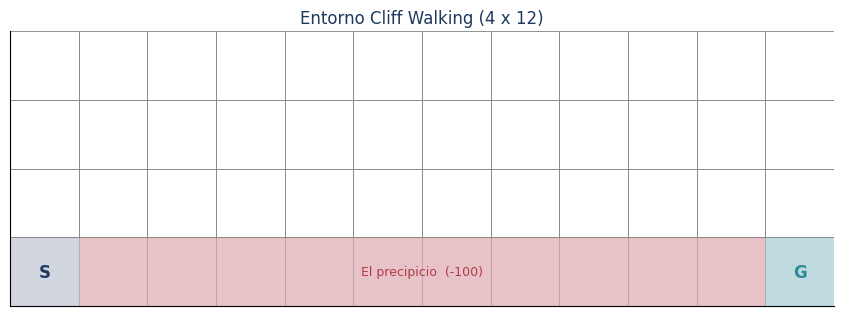

In [3]:
def dibujar_tablero(env, ax, titulo=''):
    '''Dibuja la rejilla de Cliff Walking con inicio, meta y precipicio.'''
    for r in range(env.n_filas):
        for c in range(env.n_cols):
            celda = (r, c)
            if celda in env.precipicio:
                color = COLOR_RED
                alpha = 0.30
            elif celda == env.inicio:
                color = COLOR_NAVY
                alpha = 0.20
            elif celda == env.meta:
                color = COLOR_TEAL
                alpha = 0.30
            else:
                color = 'white'
                alpha = 1.0
            ax.add_patch(patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                           facecolor=color, alpha=alpha,
                                           edgecolor='gray', linewidth=0.6))
    ax.text(0, env.n_filas - 1, 'S', ha='center', va='center',
            fontsize=12, fontweight='bold', color=COLOR_NAVY)
    ax.text(env.n_cols - 1, env.n_filas - 1, 'G', ha='center', va='center',
            fontsize=12, fontweight='bold', color=COLOR_TEAL)
    ax.text((env.n_cols - 1) / 2, env.n_filas - 1, 'El precipicio  (-100)',
            ha='center', va='center', fontsize=9, color=COLOR_RED)
    ax.set_xlim(-0.5, env.n_cols - 0.5)
    ax.set_ylim(env.n_filas - 0.5, -0.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
    if titulo:
        ax.set_title(titulo)


fig, ax = plt.subplots(figsize=(9, 3.2))
dibujar_tablero(env, ax, 'Entorno Cliff Walking (4 x 12)')
plt.tight_layout()
plt.show()

## Bloque 2 — La política $\varepsilon$-greedy

El control libre de modelo exige explorar: si el agente actuara de forma estrictamente voraz desde el inicio, las acciones óptimas penalizadas por azar al comienzo quedarían condenadas al ostracismo. La política $\varepsilon$-greedy resuelve el compromiso de la forma más sencilla:

$$
\pi(a\mid s)=
\begin{cases}
1-\varepsilon+\dfrac{\varepsilon}{|\mathcal{A}(s)|}, & \text{si } a=\arg\max_{a'}Q(s,a'),\\[0.6em]
\dfrac{\varepsilon}{|\mathcal{A}(s)|}, & \text{en otro caso.}
\end{cases}
$$

Con probabilidad $1-\varepsilon$ se explota la acción voraz; con probabilidad $\varepsilon$ se explora una acción uniformemente al azar. El desempate entre acciones de igual valor se resuelve aleatoriamente, detalle no trivial que evita sesgos sistemáticos hacia la primera acción del arreglo.

In [4]:
def epsilon_greedy(Q, s, n_acciones, epsilon, rng):
    '''Selecciona una accion segun la politica epsilon-greedy con desempate aleatorio.'''
    if rng.random() < epsilon:
        return rng.integers(n_acciones)
    # Voracidad con desempate aleatorio entre maximos
    valores = Q[s]
    maximos = np.flatnonzero(valores == valores.max())
    return rng.choice(maximos)

## Bloque 3 — SARSA (control *on-policy*)

SARSA actualiza la estimación empleando la **acción efectivamente seleccionada** en el estado sucesor, $A_{t+1}\sim\pi$:

$$
Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\bigl[\,R_{t+1}+\gamma\,Q(S_{t+1},A_{t+1})-Q(S_t,A_t)\,\bigr].
$$

Al evaluar la misma política que ejecuta —exploración incluida—, SARSA aprende a ser *prudente*: internaliza el costo esperado de los pasos aleatorios. En el estado terminal se respeta la convención $Q(\text{terminal},\cdot)=0$, de modo que el objetivo se reduce a la recompensa final.

In [5]:
def sarsa(env, n_episodios, alpha=0.5, gamma=1.0, epsilon=0.1,
          semilla=0, max_pasos=1000, epsilon_fn=None):
    '''
    SARSA tabular (control on-policy). Devuelve (Q, historia).
    Si epsilon_fn no es None, se usa epsilon_fn(episodio) en cada episodio.
    '''
    rng = np.random.default_rng(semilla)
    Q = np.zeros((env.n_estados, env.n_acciones))
    retornos = np.zeros(n_episodios)

    for ep in range(n_episodios):
        eps = epsilon_fn(ep) if epsilon_fn is not None else epsilon
        s = env.reset()
        a = epsilon_greedy(Q, s, env.n_acciones, eps, rng)
        G, pasos, terminado = 0.0, 0, False
        while not terminado and pasos < max_pasos:
            s2, r, terminado = env.paso(s, a)
            G += r
            pasos += 1
            if terminado:
                Q[s, a] += alpha * (r - Q[s, a])
            else:
                a2 = epsilon_greedy(Q, s2, env.n_acciones, eps, rng)
                Q[s, a] += alpha * (r + gamma * Q[s2, a2] - Q[s, a])
                s, a = s2, a2
        retornos[ep] = G

    return Q, {'retornos': retornos}


# Prueba rapida
Q_sarsa, hist_sarsa = sarsa(env, n_episodios=500, semilla=SEMILLA_GLOBAL)
print(f'SARSA - retorno medio en los ultimos 50 episodios: '
      f'{hist_sarsa["retornos"][-50:].mean():.1f}')

SARSA - retorno medio en los ultimos 50 episodios: -27.0


## Bloque 4 — Q-Learning (control *off-policy*)

Una única sustitución frente a SARSA transforma la naturaleza del método: el sucesor $\gamma\,Q(S_{t+1},A_{t+1})$ cede su lugar al máximo sobre las acciones,

$$
Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\bigl[\,R_{t+1}+\gamma\,\max_{a}Q(S_{t+1},a)-Q(S_t,A_t)\,\bigr].
$$

El objetivo deja de depender de la próxima acción ejecutada: codifica la política **voraz** (objetivo) mientras el agente se comporta según una política **exploratoria** (comportamiento). De ahí su carácter *off-policy*. Adviértase que ya no se requiere elegir $A'$.

In [6]:
def q_learning(env, n_episodios, alpha=0.5, gamma=1.0, epsilon=0.1,
               semilla=0, max_pasos=1000, epsilon_fn=None):
    '''
    Q-Learning tabular (control off-policy). Devuelve (Q, historia).
    '''
    rng = np.random.default_rng(semilla)
    Q = np.zeros((env.n_estados, env.n_acciones))
    retornos = np.zeros(n_episodios)

    for ep in range(n_episodios):
        eps = epsilon_fn(ep) if epsilon_fn is not None else epsilon
        s = env.reset()
        G, pasos, terminado = 0.0, 0, False
        while not terminado and pasos < max_pasos:
            a = epsilon_greedy(Q, s, env.n_acciones, eps, rng)
            s2, r, terminado = env.paso(s, a)
            G += r
            pasos += 1
            if terminado:
                Q[s, a] += alpha * (r - Q[s, a])
            else:
                Q[s, a] += alpha * (r + gamma * Q[s2].max() - Q[s, a])
            s = s2
        retornos[ep] = G

    return Q, {'retornos': retornos}


# Prueba rapida
Q_ql, hist_ql = q_learning(env, n_episodios=500, semilla=SEMILLA_GLOBAL)
print(f'Q-Learning - retorno medio en los ultimos 50 episodios: '
      f'{hist_ql["retornos"][-50:].mean():.1f}')

Q-Learning - retorno medio en los ultimos 50 episodios: -46.1


## Bloque 5 — Réplica del experimento canónico (Sutton & Barto, figura 6.4)

Comparamos el **retorno por episodio** de ambos métodos durante el aprendizaje, con $\varepsilon=0.1$ constante, $\alpha=0.5$ y $\gamma=1$. Para atenuar la varianza del muestreo promediamos sobre $N=150$ réplicas independientes, cada una con su propio generador derivado de la semilla global. Se aplica además un suavizado por media móvil, fiel a la presentación original.

La predicción teórica es nítida: SARSA, que evalúa su política exploratoria, aprende la **ruta segura** y obtiene un retorno en línea *superior*; Q-Learning, que aprende la política óptima pero la ejecuta con ruido $\varepsilon$, se despeña con frecuencia al precipicio y exhibe un retorno en línea *inferior*, pese a conocer el camino más corto.

In [7]:
def correr_replicas_control(metodo, n_replicas, n_episodios, semilla_base, **kwargs):
    '''Ejecuta n_replicas independientes; devuelve matriz[i, e] = retorno en replica i, episodio e.'''
    matriz = np.zeros((n_replicas, n_episodios))
    for i in range(n_replicas):
        _, hist = metodo(env, n_episodios=n_episodios, semilla=semilla_base + i, **kwargs)
        matriz[i, :] = hist['retornos']
    return matriz


def media_movil(x, ventana=10):
    '''Media movil causal simple.'''
    nucleo = np.ones(ventana) / ventana
    return np.convolve(x, nucleo, mode='valid')


N_REPLICAS = 150
N_EPISODIOS = 500

print(f'Ejecutando {N_REPLICAS} replicas de SARSA ...')
ret_sarsa = correr_replicas_control(sarsa, N_REPLICAS, N_EPISODIOS, SEMILLA_GLOBAL,
                                    alpha=0.5, epsilon=0.1, gamma=1.0)
print(f'Ejecutando {N_REPLICAS} replicas de Q-Learning ...')
ret_ql = correr_replicas_control(q_learning, N_REPLICAS, N_EPISODIOS, SEMILLA_GLOBAL,
                                 alpha=0.5, epsilon=0.1, gamma=1.0)
print('Replicas completadas.')

Ejecutando 150 replicas de SARSA ...


Ejecutando 150 replicas de Q-Learning ...


Replicas completadas.


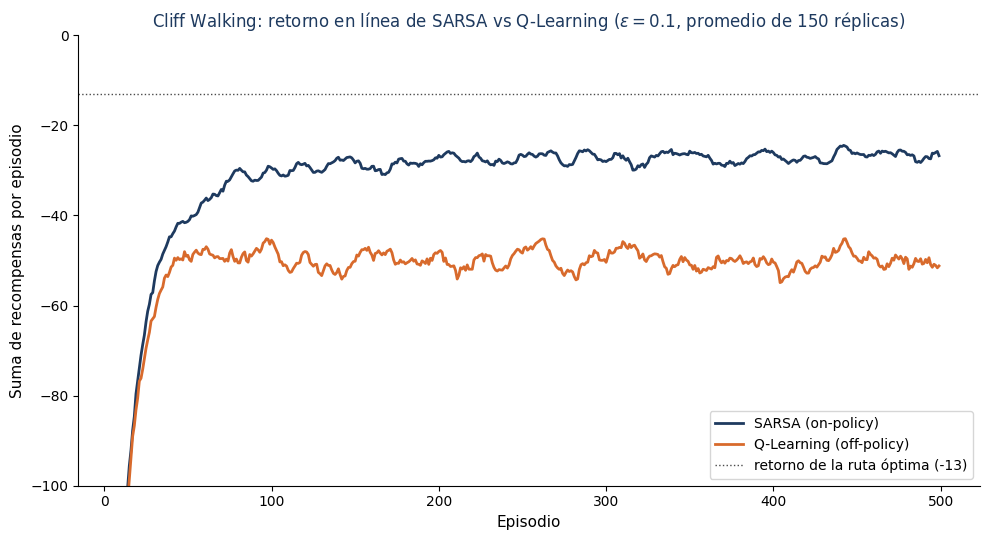

Retorno medio asintotico (ultimos 100 episodios):
  SARSA      : -26.8
  Q-Learning : -50.3


In [8]:
media_sarsa = ret_sarsa.mean(axis=0)
media_ql = ret_ql.mean(axis=0)

VENTANA = 10
s_suave = media_movil(media_sarsa, VENTANA)
q_suave = media_movil(media_ql, VENTANA)
ejes_x = np.arange(VENTANA - 1, N_EPISODIOS)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(ejes_x, s_suave, color=COLOR_NAVY, linewidth=2, label='SARSA (on-policy)')
ax.plot(ejes_x, q_suave, color=COLOR_ORANGE, linewidth=2, label='Q-Learning (off-policy)')
ax.axhline(-13, color=COLOR_GRAY, linestyle=':', linewidth=1,
           label='retorno de la ruta óptima (-13)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Suma de recompensas por episodio')
ax.set_title('Cliff Walking: retorno en línea de SARSA vs Q-Learning '
             f'($\\varepsilon=0.1$, promedio de {N_REPLICAS} réplicas)')
ax.set_ylim(-100, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Retorno medio asintotico (ultimos 100 episodios):')
print(f'  SARSA      : {media_sarsa[-100:].mean():.1f}')
print(f'  Q-Learning : {media_ql[-100:].mean():.1f}')

**Lectura del resultado.** La curva de SARSA se sitúa por encima de la de Q-Learning durante todo el aprendizaje. He aquí la *paradoja del rendimiento en línea*: Q-Learning aprende la política óptima —la que bordea el precipicio—, pero al ejecutarla con exploración $\varepsilon$ cae al vacío con frecuencia, lo que deteriora su retorno observado. SARSA, consciente de su propia torpeza exploratoria, rodea el peligro por la fila superior. La línea de referencia en $-13$ marca el retorno de la ruta óptima sin error (13 pasos de coste $-1$).

## Bloque 6 — Las políticas aprendidas: ruta segura frente a ruta óptima

Extraemos la política voraz de cada matriz $Q$ y trazamos la trayectoria que el agente seguiría sin exploración. La diferencia es la firma conductual de cada método.

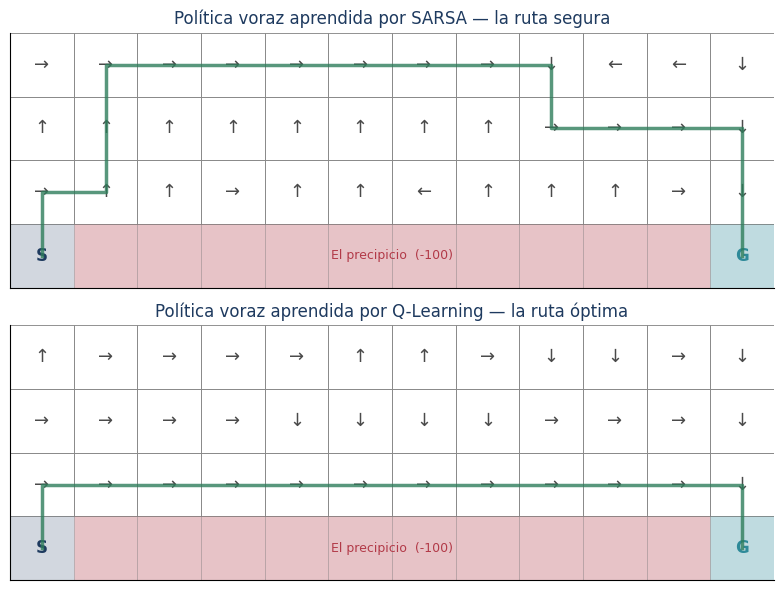

In [9]:
def politica_voraz(env, Q):
    '''Devuelve un arreglo con la accion voraz por estado.'''
    return Q.argmax(axis=1)


def trayectoria_voraz(env, Q, max_pasos=200):
    '''Sigue la politica voraz desde el inicio y devuelve la lista de celdas visitadas.'''
    s = env.reset()
    camino = [env.coord(s)]
    for _ in range(max_pasos):
        a = int(Q[s].argmax())
        s2, _, terminado = env.paso(s, a)
        camino.append(env.coord(s2))
        if terminado:
            break
        if s2 == s:  # estancamiento
            break
        s = s2
    return camino


def dibujar_politica(env, Q, ax, titulo):
    '''Dibuja el tablero, las flechas de la politica voraz y la trayectoria resultante.'''
    dibujar_tablero(env, ax, titulo)
    politica = politica_voraz(env, Q)
    for r in range(env.n_filas):
        for c in range(env.n_cols):
            celda = (r, c)
            if celda in env.precipicio or celda == env.meta or celda == env.inicio:
                continue
            a = politica[env.idx(celda)]
            ax.text(c, r, env.flechas[a], ha='center', va='center',
                    fontsize=13, color=COLOR_GRAY)
    # Trayectoria voraz
    camino = trayectoria_voraz(env, Q)
    xs = [c for (r, c) in camino]
    ys = [r for (r, c) in camino]
    ax.plot(xs, ys, color=COLOR_GREEN, linewidth=2.5, alpha=0.8, zorder=3)


fig, axes = plt.subplots(2, 1, figsize=(9, 6))
dibujar_politica(env, Q_sarsa, axes[0], 'Política voraz aprendida por SARSA — la ruta segura')
dibujar_politica(env, Q_ql, axes[1], 'Política voraz aprendida por Q-Learning — la ruta óptima')
plt.tight_layout()
plt.show()

La evidencia visual confirma la teoría: **SARSA** aprende a alejarse del borde, recorriendo la fila superior antes de descender hacia la meta; **Q-Learning** aprende a pegarse al precipicio, la trayectoria de máximo retorno cuando se la sigue sin error. Ambas políticas son racionales bajo su propio criterio de evaluación.

## Bloque 7 — El efecto de $\varepsilon$ y su decaimiento (condición GLIE)

Una exploración constante impide alcanzar una política óptima determinista. La condición **GLIE** (*Greedy in the Limit with Infinite Exploration*) prescribe decaer $\varepsilon$ hacia cero conservando, no obstante, visitas infinitas a cada par. Empleamos un decaimiento armónico $\varepsilon_k = \varepsilon_0 / (1 + k\cdot\tau)$ y examinamos dos manifestaciones distintas de su efecto: la **política voraz** finalmente aprendida y el **retorno en línea** durante el aprendizaje.

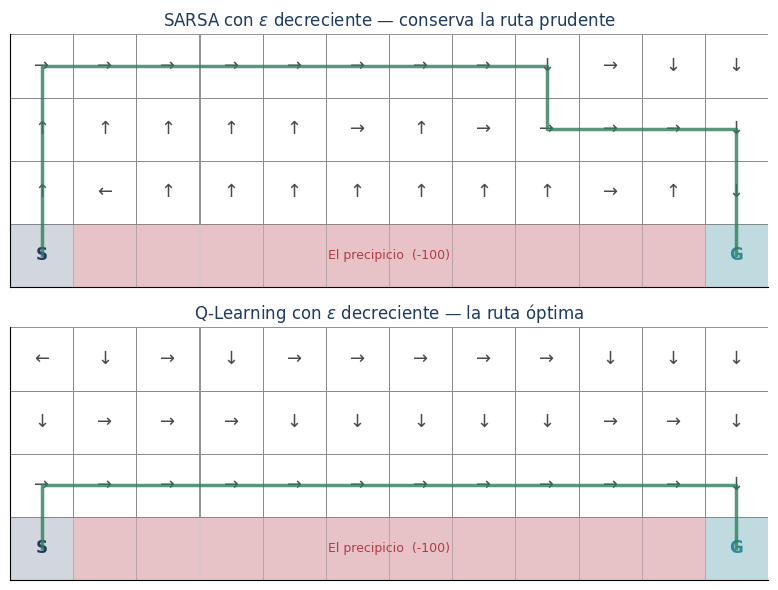

Longitud de la ruta voraz final (optimo = 13 pasos):
  SARSA      (eps decreciente): 17
  Q-Learning (eps decreciente): 13


In [10]:
def epsilon_decreciente(eps0=0.5, tau=0.01):
    '''Devuelve una funcion epsilon_fn(episodio) con decaimiento armonico.'''
    return lambda k: eps0 / (1.0 + k * tau)


N_EP_DECAY = 1000
Q_sarsa_d, hist_sarsa_d = sarsa(env, n_episodios=N_EP_DECAY, alpha=0.5, gamma=1.0,
                                semilla=SEMILLA_GLOBAL,
                                epsilon_fn=epsilon_decreciente(0.5, 0.01))
Q_ql_d, hist_ql_d = q_learning(env, n_episodios=N_EP_DECAY, alpha=0.5, gamma=1.0,
                               semilla=SEMILLA_GLOBAL,
                               epsilon_fn=epsilon_decreciente(0.5, 0.01))

fig, axes = plt.subplots(2, 1, figsize=(9, 6))
dibujar_politica(env, Q_sarsa_d, axes[0],
                 'SARSA con $\\varepsilon$ decreciente — conserva la ruta prudente')
dibujar_politica(env, Q_ql_d, axes[1],
                 'Q-Learning con $\\varepsilon$ decreciente — la ruta óptima')
plt.tight_layout()
plt.show()

print('Longitud de la ruta voraz final (optimo = 13 pasos):')
print(f'  SARSA      (eps decreciente): {len(trayectoria_voraz(env, Q_sarsa_d)) - 1}')
print(f'  Q-Learning (eps decreciente): {len(trayectoria_voraz(env, Q_ql_d)) - 1}')

**Una sutileza que conviene no ocultar.** Dentro de este horizonte finito, la política voraz de Q-Learning coincide ya con la ruta óptima, mientras que la de SARSA preserva un margen de seguridad. La razón es doble. Primero, la convergencia de SARSA a $q_*$ es *asintótica* y exige las **dos** condiciones del teorema (Singh y colaboradores, 2000): no basta con que $\varepsilon$ decaiga (GLIE), también el paso $\alpha$ debe satisfacer Robbins-Monro. Con $\alpha=0.5$ constante, la estimación nunca se asienta del todo y la política on-policy retiene su cautela. Segundo, las celdas contiguas al precipicio se visitan cada vez menos al desvanecerse la exploración, de modo que conservan los valores pesimistas heredados de las caídas tempranas. SARSA debería *desaprender* esa prudencia, y ello ocurre con lentitud. La distinción on-policy / off-policy se revela así no como un destino último diferente, sino como una **velocidad y un sesgo de aprendizaje** distintos.

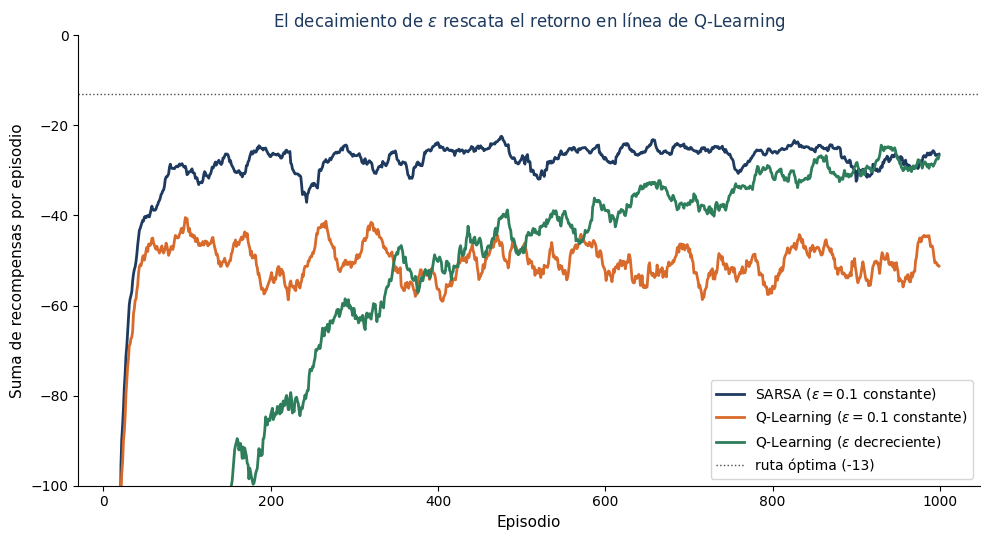

Retorno medio en linea (ultimos 100 episodios):
  SARSA      (eps=0.1)        : -28.1
  Q-Learning (eps=0.1)        : -50.6
  Q-Learning (eps decreciente): -28.1


In [11]:
# El beneficio concreto del decaimiento: el retorno EN LINEA de Q-Learning
N_REP_COMP = 30
ret_ql_const = correr_replicas_control(q_learning, N_REP_COMP, N_EP_DECAY, SEMILLA_GLOBAL,
                                       alpha=0.5, epsilon=0.1, gamma=1.0)
ret_ql_decay = correr_replicas_control(q_learning, N_REP_COMP, N_EP_DECAY, SEMILLA_GLOBAL,
                                       alpha=0.5, gamma=1.0,
                                       epsilon_fn=epsilon_decreciente(0.5, 0.01))
ret_sarsa_const = correr_replicas_control(sarsa, N_REP_COMP, N_EP_DECAY, SEMILLA_GLOBAL,
                                          alpha=0.5, epsilon=0.1, gamma=1.0)

fig, ax = plt.subplots(figsize=(10, 5.5))
for serie, color, etq in [
    (ret_sarsa_const, COLOR_NAVY, 'SARSA ($\\varepsilon=0.1$ constante)'),
    (ret_ql_const, COLOR_ORANGE, 'Q-Learning ($\\varepsilon=0.1$ constante)'),
    (ret_ql_decay, COLOR_GREEN, 'Q-Learning ($\\varepsilon$ decreciente)')]:
    m = serie.mean(axis=0)
    suave = media_movil(m, 20)
    ax.plot(np.arange(19, N_EP_DECAY), suave, color=color, linewidth=2, label=etq)
ax.axhline(-13, color=COLOR_GRAY, linestyle=':', linewidth=1, label='ruta óptima (-13)')
ax.set_xlabel('Episodio'); ax.set_ylabel('Suma de recompensas por episodio')
ax.set_title('El decaimiento de $\\varepsilon$ rescata el retorno en línea de Q-Learning')
ax.set_ylim(-100, 0); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print('Retorno medio en linea (ultimos 100 episodios):')
print(f'  SARSA      (eps=0.1)        : {ret_sarsa_const.mean(axis=0)[-100:].mean():.1f}')
print(f'  Q-Learning (eps=0.1)        : {ret_ql_const.mean(axis=0)[-100:].mean():.1f}')
print(f'  Q-Learning (eps decreciente): {ret_ql_decay.mean(axis=0)[-100:].mean():.1f}')

Al desvanecerse $\varepsilon$, Q-Learning deja de despeñarse por sus propios pasos exploratorios: su retorno en línea remonta desde el entorno de $-50$ hasta rozar el óptimo de $-13$, alcanzando e incluso superando a SARSA hacia el final. He aquí la lección operativa: si lo que importa es el desempeño *durante* el aprendizaje en un entorno peligroso, conviene decaer la exploración o, alternativamente, preferir un método on-policy.

## Bloque 8 — Primer contacto con CartPole: la antesala de la aproximación de funciones

El formato tabular reposa sobre una premisa frágil: un número finito y manejable de estados. CartPole (Gymnasium) lo quiebra, pues su estado es **continuo** —posición y velocidad del carro, ángulo y velocidad angular del péndulo—. Para aplicar Q-Learning tabular debemos **discretizar** cada dimensión en intervalos, lo que multiplica la cardinalidad del espacio: el número de estados es el producto de los intervalos de cada dimensión. Es la *maldición de la dimensionalidad* en acción, y la motivación directa de la aproximación de funciones que abordaremos en la Clase 5.

> La siguiente celda instala `gymnasium` si no estuviera disponible (necesario en Google Colab).

In [12]:
# Instalacion protegida para Google Colab
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gymnasium'], check=True)
    import gymnasium as gym
print('gymnasium', gym.__version__)

gymnasium 1.3.0


In [13]:
# Discretizacion del estado continuo de CartPole en intervalos por dimension
LIMITES = [(-2.4, 2.4), (-3.0, 3.0), (-0.21, 0.21), (-3.5, 3.5)]
N_BINS = [3, 3, 8, 8]   # mas finura en angulo y velocidad angular

bordes = [np.linspace(lo, hi, n + 1)[1:-1] for (lo, hi), n in zip(LIMITES, N_BINS)]
N_ESTADOS_CP = int(np.prod(N_BINS))

def discretizar(obs):
    '''Convierte una observacion continua en un indice de estado discreto.'''
    idx = 0
    for x, b, n in zip(obs, bordes, N_BINS):
        idx = idx * n + int(np.digitize(x, b))
    return idx

print(f'Espacio discretizado de CartPole: {N_ESTADOS_CP} estados (= {"x".join(map(str,N_BINS))}).')
print('Comparese con los 48 estados de Cliff Walking: la explosion combinatoria es evidente.')

Espacio discretizado de CartPole: 576 estados (= 3x3x8x8).
Comparese con los 48 estados de Cliff Walking: la explosion combinatoria es evidente.


In [14]:
def q_learning_cartpole(n_episodios=2000, alpha=0.1, gamma=0.99,
                        eps0=1.0, eps_min=0.02, decay=0.997, semilla=SEMILLA_GLOBAL):
    '''Q-Learning tabular sobre CartPole discretizado. Devuelve la lista de retornos.'''
    entorno = gym.make('CartPole-v1')
    rng = np.random.default_rng(semilla)
    Q = np.zeros((N_ESTADOS_CP, entorno.action_space.n))
    retornos = []
    eps = eps0
    for ep in range(n_episodios):
        obs, _ = entorno.reset(seed=int(semilla + ep))
        s = discretizar(obs)
        terminado = truncado = False
        G = 0.0
        while not (terminado or truncado):
            if rng.random() < eps:
                a = rng.integers(entorno.action_space.n)
            else:
                a = int(Q[s].argmax())
            obs2, r, terminado, truncado, _ = entorno.step(a)
            s2 = discretizar(obs2)
            objetivo = r + (0.0 if terminado else gamma * Q[s2].max())
            Q[s, a] += alpha * (objetivo - Q[s, a])
            s = s2
            G += r
        retornos.append(G)
        eps = max(eps_min, eps * decay)
    entorno.close()
    return Q, np.array(retornos)


print('Entrenando Q-Learning tabular sobre CartPole discretizado ...')
Q_cp, ret_cp = q_learning_cartpole()
print(f'Retorno medio (ultimos 100 episodios): {ret_cp[-100:].mean():.1f} '
      f'(maximo posible: 500).')

Entrenando Q-Learning tabular sobre CartPole discretizado ...


Retorno medio (ultimos 100 episodios): 252.4 (maximo posible: 500).


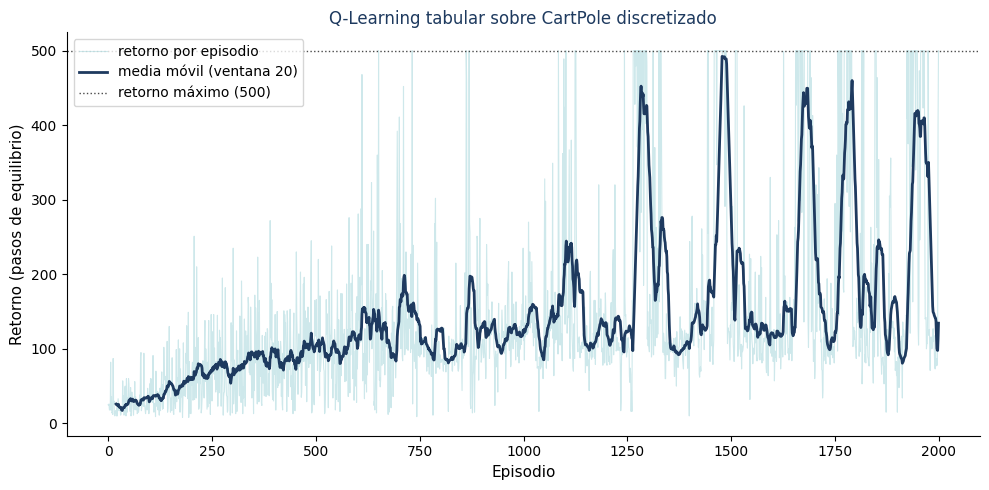

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ret_cp, color=COLOR_LIGHT_TEAL, alpha=0.5, linewidth=0.8, label='retorno por episodio')
if len(ret_cp) >= 20:
    ax.plot(np.arange(19, len(ret_cp)), media_movil(ret_cp, 20),
            color=COLOR_NAVY, linewidth=2, label='media móvil (ventana 20)')
ax.axhline(500, color=COLOR_GRAY, linestyle=':', linewidth=1, label='retorno máximo (500)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Retorno (pasos de equilibrio)')
ax.set_title('Q-Learning tabular sobre CartPole discretizado')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

El agente tabular aprende a sostener el péndulo durante un número creciente de pasos, pero la discretización paga un precio: ignora la vecindad entre estados parecidos y multiplica la memoria requerida. En la **Clase 5** sustituiremos la tabla por una función parametrizada $\hat{q}(s,a;\mathbf{w})$ —primero lineal, luego una red neuronal—, lo que dará lugar a DQN. Q-Learning, el algoritmo de hoy, será su corazón conceptual.

## Ejercicios propuestos

Los siguientes ejercicios extienden las implementaciones de este cuaderno. El componente evaluado de la Unidad 3 tiene como plazo de entrega el **1 de junio, 23:59 hs**.

### Ejercicios obligatorios (formales)

1. **Ejercicio teórico 1.** Demuestre el teorema de mejora para políticas $\varepsilon$-greedy: si $\pi'$ es la política $\varepsilon$-greedy respecto de $Q^\pi$, entonces $Q^\pi(s,\pi'(s))\ge V^\pi(s)$ para todo $s$, y por ende $V^{\pi'}\ge V^\pi$. Identifique con precisión el papel de la cota $\varepsilon/|\mathcal{A}(s)|$.

2. **Ejercicio teórico 2.** Exhiba la sustitución exacta de la política $\pi$ que reduce la actualización de *Expected SARSA*,
   $$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\Bigl[R_{t+1}+\gamma\textstyle\sum_a \pi(a\mid S_{t+1})Q(S_{t+1},a)-Q(S_t,A_t)\Bigr],$$
   a la actualización de Q-Learning. Discuta por qué ello revela su carácter *off-policy*.

3. **Ejercicio computacional 1.** Reproduzca la figura del Bloque 5 variando el número de réplicas a $N=500$ y barriendo $\varepsilon\in\{0.05, 0.1, 0.2\}$. ¿Cómo se modifica la brecha entre SARSA y Q-Learning al aumentar $\varepsilon$? Justifique.

4. **Ejercicio computacional 2.** Implemente **Expected SARSA** sobre Cliff Walking y compárelo con SARSA y Q-Learning en términos de retorno en línea y varianza entre réplicas. ¿Confirma usted la reducción de varianza que predice la teoría?

### Ejercicios opcionales (de profundización)

5. **Ejercicio integrador (sesgo de maximización).** Construya el MDP de dos estados del ejemplo 6.7 de Sutton & Barto y cuantifique empíricamente la sobreestimación de Q-Learning. Implemente **doble Q-Learning** y verifique la corrección del sesgo.

6. **Ejercicio avanzado (CartPole).** Estudie el efecto de la granularidad de la discretización (`N_BINS`) sobre el desempeño y la velocidad de aprendizaje en CartPole. Documente el compromiso entre resolución y número de estados, y argumente por qué la aproximación de funciones constituye la salida natural.

---

### Referencias del cuaderno

* Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2.ª ed.). MIT Press. Capítulo 6, secciones 6.4 a 6.7.
* Zhao, S. (2024). *Mathematical Foundations of Reinforcement Learning*. Springer. Capítulo 7, secciones 7.2 a 7.4.
* Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3), 279–292.
* van Hasselt, H. (2010). Double Q-learning. *Advances in Neural Information Processing Systems*, 23.

---

*Cuaderno preparado para la Clase 4 del curso «Aprendizaje por Refuerzo: Fundamentos y Aplicaciones», Universidad Austral, mayo de 2026.*